
### EX: Email Phishing Detection

In this exercise, we will classify emails and visualize exactly *which* words are driving the model's decisions. You will execute the following steps:

* **Generate Data:** Create a dataset of Benign (Ham) and Malicious (Spam) emails.
* **Train Model:** Vectorize the text and train the Naive Bayes classifier.
* **Extract Log Probabilities:** Look inside the "brain" of the model to extract the mathematical weights (log probabilities) it assigned to every single word in the vocabulary.
* **Visualize:** Plot a horizontal bar chart showing the top 10 most "malicious" words to understand how the independence assumption manifests in the real world.

In [1]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

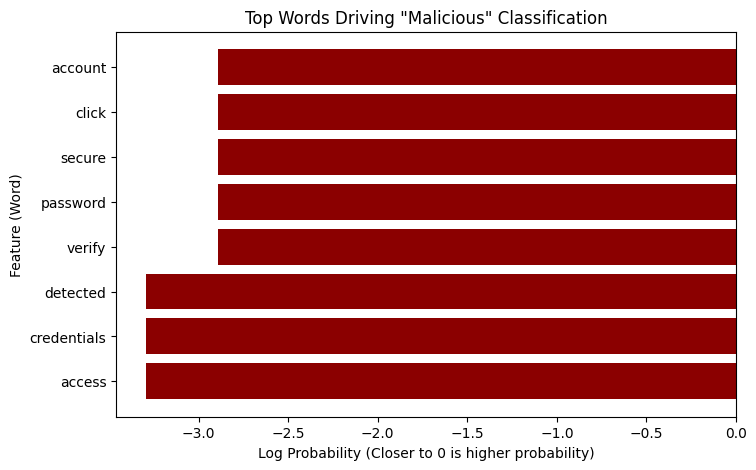

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


# 1. Synthetic Phishing Dataset
email_data = {
    'Email': [
        "meeting at 0900 regarding training",
        "URGENT: reset your network password immediately",
        "please review the attached briefing document",
        "click here to verify your secure login credentials",
        "lunch menu for the week is attached", 
        "warning: unauthorized access detected click link to secure account",
        "reminder to submit your leave request",
        "your mailbox is full please verify account password"
    ],
    'Label': ['Benign', 'Malicious', 'Benign', 'Malicious', 'Benign', 'Malicious', 'Benign', 'Malicious']
}
df_emails = pd.DataFrame(email_data)

# 2. Train Model
vec_emails = CountVectorizer(stop_words='english') # Removes words like "the", "at", "your"
X_emails = vec_emails.fit_transform(df_emails['Email'])
nb_emails = MultinomialNB()
nb_emails.fit(X_emails, df_emails['Label'])

# 3. Extract Feature Log Probabilities
# nb_emails.feature_log_prob_[1] contains the probabilities for the 'Malicious' class
words = vec_emails.get_feature_names_out()
malicious_log_probs = nb_emails.feature_log_prob_[1] 

# Create a DataFrame for visualization
df_features = pd.DataFrame({'Word': words, 'Malicious_Log_Prob': malicious_log_probs})
df_top_malicious = df_features.sort_values(by='Malicious_Log_Prob', ascending=False).head(8)

# 4. Plot the most dangerous words
plt.figure(figsize=(8, 5))
plt.barh(df_top_malicious['Word'], df_top_malicious['Malicious_Log_Prob'], color='darkred')
plt.gca().invert_yaxis() # Put the highest probability at the top
plt.title('Top Words Driving "Malicious" Classification')
plt.xlabel('Log Probability (Closer to 0 is higher probability)')
plt.ylabel('Feature (Word)')
plt.show()



### Interpreting the Results

The bar chart reveals the inner workings of the model. Words like "password", "secure", and "verify" have the highest log probabilities (closest to 0) in the Malicious class.

Because of the naive independence assumption, if an adversary writes an email saying "verify password secure login", the model multiplies all these high probabilities together. It treats each word as a totally separate, damning piece of evidence. While a statistician would argue this math is technically flawed (because those words frequently appear together in the same sentence), the Cyber Warfare operator doesn't care—the model successfully quarantined the threat.
